# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [41]:
import pandas as pd
import numpy as np

enrollment = pd.read_csv(
    "https://raw.githubusercontent.com/kevindavisross/data301/main/data/enron_email.csv"
)

corpus = enrollment['body'].fillna('') 

enrollment.head()

,subject,body,spam
0,mirant 4 / 01,we invoiced mirant americas for deal 705989 an...,0.0
1,re : lobo payout,because the payback was done for october 2001 ...,0.0
2,entex transaction 7,"for december 1999 , since the volumes for tran...",0.0
3,re : hpl transport contracts,i would think that the first contract should g...,0.0
4,welcome to aol instant messenger !,welcome to the aol instant messenger ( sm ) se...,0.0


2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


**I would treat each email as a seperate document where test is divided into words and puncutation is removed. Then I would count the number of words in each email. So now every row represents an email and each column is a word. Each value represents the number of time that word is in an email.**

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [59]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
tf = cv.fit_transform(corpus)

tf_df = pd.DataFrame(
    tf.toarray(),
    columns=cv.get_feature_names_out(),
    index=enrollment.index
)

tf_df.head()

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


**Document frequency is the number of documents that have a specified word. Inverse document frequency gives more importance to uncommon words and less importance to common ones. We would use TF-IDF over TF because TF gives priority to frequenty occuring words, while TF-IDF does not prioritize common words as much and focuses on words that distingush an email from another.**

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf = tfidf_vectorizer.fit_transform(corpus)

tfidf_df = pd.DataFrame(
    tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=enrollment.index
)

tfidf_df.head()

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.097060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


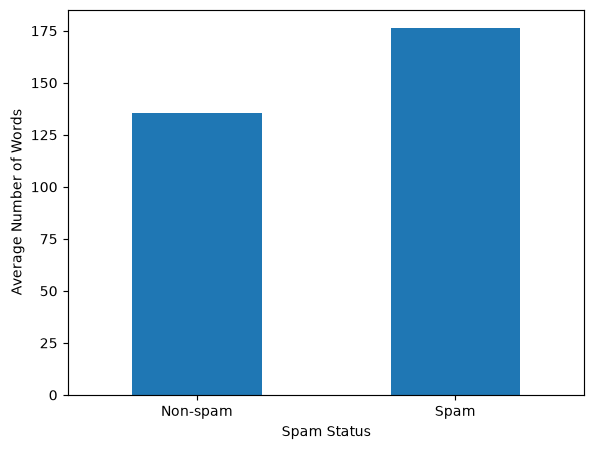

Top non-spam words:


the      0.082967
ect      0.075379
to       0.065038
enron    0.051935
hou      0.040775
xls      0.040757
for      0.038417
000      0.036508
on       0.035399
and      0.034985
Name: 0.0, dtype: float64

Top spam words:


the     0.057534
to      0.050273
and     0.049189
you     0.042117
of      0.040379
your    0.034473
in      0.029420
for     0.028624
is      0.025543
this    0.024971
Name: 1.0, dtype: float64

In [63]:
import matplotlib.pyplot as plt

known = enrollment["spam"].notna()

word_counts = tf_df.loc[known].sum(axis=1)

average_length = word_counts.groupby(
    enrollment.loc[known, "spam"]
).mean()

average_length.plot(kind="bar")
plt.xlabel("Spam Status")
plt.ylabel("Average Number of Words")
plt.xticks([0, 1], ["Non-spam", "Spam"], rotation=0)
plt.show()

average_tfidf = tfidf_df.loc[known].groupby(
    enrollment.loc[known, "spam"]
).mean()

print("Top non-spam words:")
display(average_tfidf.loc[0].nlargest(10))

print("Top spam words:")
display(average_tfidf.loc[1].nlargest(10))

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

**We can compare each unknown email to emails with known spam. The TF or TF-IDF matrices can be used to calculate the similarity between the emails. If an unknown email is similar to other known emails, we could classify it as spam. If not, then not spam.**

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [69]:
from sklearn.metrics.pairwise import cosine_distances

target_index = 1980

target_pos = enrollment.index.get_loc(target_index)

known_pos = np.flatnonzero(known_mask.to_numpy())

tf_distances = cosine_distances(
    tf_matrix[target_pos],
    tf_matrix[known_pos]
).ravel()

tf_distance_results = pd.DataFrame({
    "email_index": enrollment.index[known_pos],
    "subject": enrollment.iloc[known_pos]["subject"].to_numpy(),
    "spam": enrollment.iloc[known_pos]["spam"].to_numpy(),
    "cosine_distance": tf_distances
})

tf_distance_results.head()

,email_index,subject,spam,cosine_distance
0,0,mirant 4 / 01,0.0,0.736928
1,1,re : lobo payout,0.0,0.542990
2,2,entex transaction 7,0.0,0.775802
3,3,re : hpl transport contracts,0.0,0.653954
4,4,welcome to aol instant messenger !,0.0,0.519088


9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [70]:
nearest_tf = tf_results.sort_values("distance")
nearest_tf.head(10)

tf_prediction = int(
    nearest_tf.head(5)["spam"].mode().iloc[0]
)
print("Spam" if tf_prediction == 1 else "Non-spam")

Spam


10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [87]:
tfidf_distances = cosine_distances(
    tfidf_matrix[target_pos],
    tfidf_matrix[known_pos]
).ravel()

tfidf_distance_results = pd.DataFrame({
    "email_index": enrollment.index[known_pos],
    "subject": enrollment.iloc[known_pos]["subject"].to_numpy(),
    "spam": enrollment.iloc[known_pos]["spam"].to_numpy(),
    "cosine_distance": tfidf_distances
})

nearest_tfidf = tfidf_distance_results.sort_values(
    "cosine_distance"
)

nearest_tfidf.head()

,email_index,subject,spam,cosine_distance
1032,1032,can you facilitate ?,1.0,0.755245
1977,1977,reply soon ! ! !,1.0,0.780917
48,48,tetco / hpl ( enerfin ) meter # 986892,0.0,0.787975
1689,1689,how are you today ?,1.0,0.790205
1796,1796,urgent assistance,1.0,0.795094


In [95]:
k = 5
target_index = 1980

prediction_tf = int(
    nearest_tf.head(k)["spam"].mode().iloc[0]
)

tfidf_neighbors = nearest_tfidf.head(k)

prediction_tfidf = int(
    tfidf_neighbors["spam"].mode().iloc[0]
)

tfidf_votes = int(
    (tfidf_neighbors["spam"] == prediction_tfidf).sum()
)

tfidf_label = (
    "spam" if prediction_tfidf == 1 else "not spam"
)

print(
    f"Using TF-IDF, email {target_index} is classified as "
    f"{tfidf_label} because {tfidf_votes} of its {k} nearest "
    f"neighbors have that classification."
)

if prediction_tf == prediction_tfidf:
    print("The TF and TF-IDF classifications are the same.")
else:
    print("The TF and TF-IDF classifications are different.")

Using TF-IDF, email 1980 is classified as spam because 4 of its 5 nearest neighbors have that classification.
The TF and TF-IDF classifications are the same.


11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [91]:
unknown = enrollment["spam"].isna()

def predict_status(matrix, k=5):
    distances = pairwise_distances(
        matrix.loc[unknown],
        matrix.loc[known],
        metric="cosine"
    )

    known_labels = enrollment.loc[known, "spam"].to_numpy()
    predictions = []

    for row in distances:
        closest = np.argsort(row)[:k]
        prediction = pd.Series(
            known_labels[closest]
        ).mode().iloc[0]
        predictions.append(int(prediction))

    return predictions

guesses = enrollment.loc[unknown, ["subject"]].copy()
guesses["TF_guess"] = predict_status(tf_df)
guesses["TFIDF_guess"] = predict_status(tfidf_df)

guesses

,subject,TF_guess,TFIDF_guess
1980,let ' s talk about your home loan .,1,1
1981,intraday eastrans nomination change for 9 / 6 ...,0,0
1982,"frontrea plant , gas",0,0
1983,re : meter 5892,0,0
1984,eastrans nomination change effective 8 / 3 / 00,0,0
1985,customer reciept # 4359 bn winkle,1,1
1986,internet pharmacy - smart prices,1,1
1987,victory at last,1,1
1988,free pay per view,1,1
1989,87 % off for all new software . darned canniba...,0,0
